<a href="https://colab.research.google.com/github/Archu403/Repository-name-Care-Transition-Efficiency-Analytics/blob/main/Care_Transition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program.csv to HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (1).csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             720 non-null    object
 1   Children apprehended and placed in CBP custody*  720 non-null    int64 
 2   Children in CBP custody                          720 non-null    int64 
 3   Children transferred out of CBP custody          720 non-null    int64 
 4   Children in HHS Care                             720 non-null    object
 5   Children discharged from HHS Care                720 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 33.9+ KB


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [6]:
df.isnull().sum()

,0
Date,0
Children apprehended and placed in CBP custody*,0
Children in CBP custody,0
Children transferred out of CBP custody,0
Children in HHS Care,0
Children discharged from HHS Care,0


In [7]:
# Remove commas from all numeric columns

cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col])

In [8]:
import pandas as pd

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check column names
print(df.columns)

# Check for missing values
print(df.isnull().sum())

# Remove duplicate rows (if any)
df = df.drop_duplicates()

# Display basic information
df.info()

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')
Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64 

In [10]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


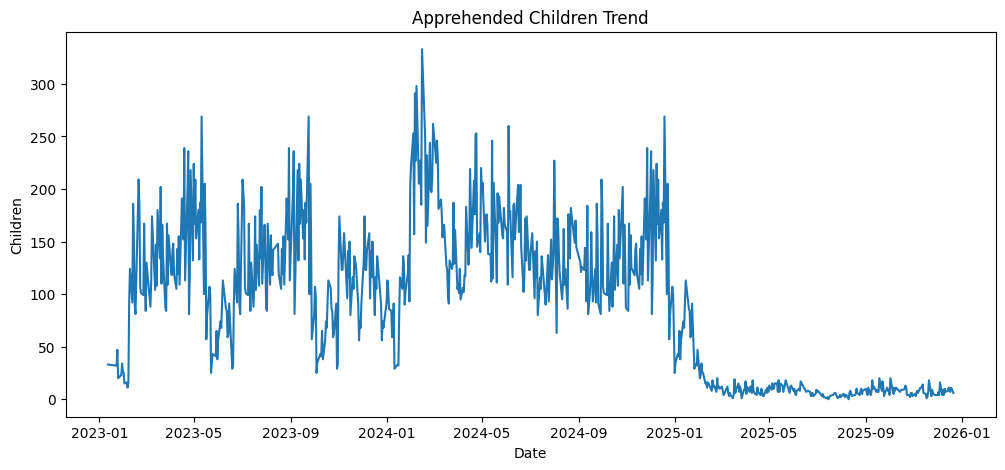

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children apprehended and placed in CBP custody*'])
plt.title('Apprehended Children Trend')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

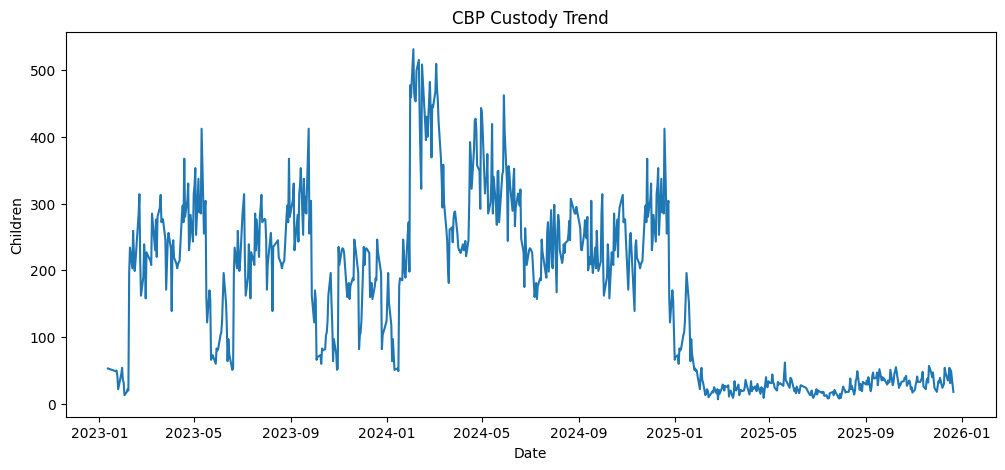

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children in CBP custody'])
plt.title('CBP Custody Trend')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

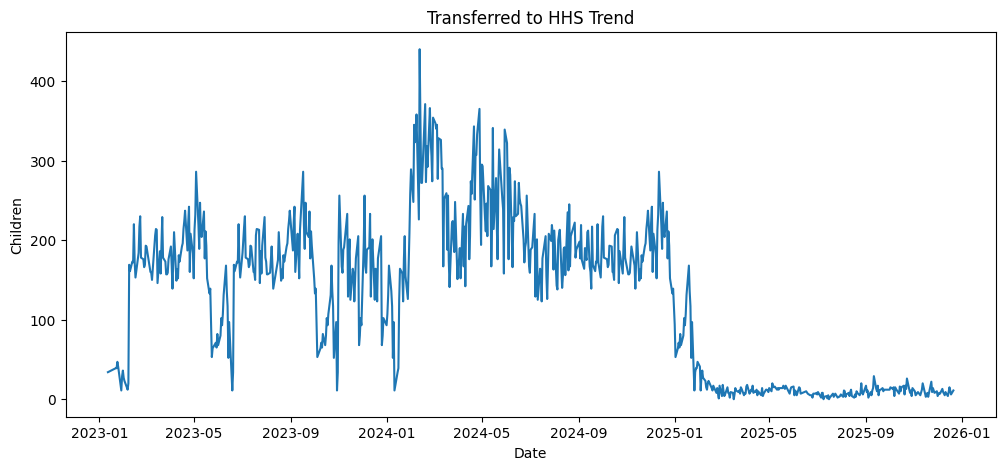

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children transferred out of CBP custody'])
plt.title('Transferred to HHS Trend')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

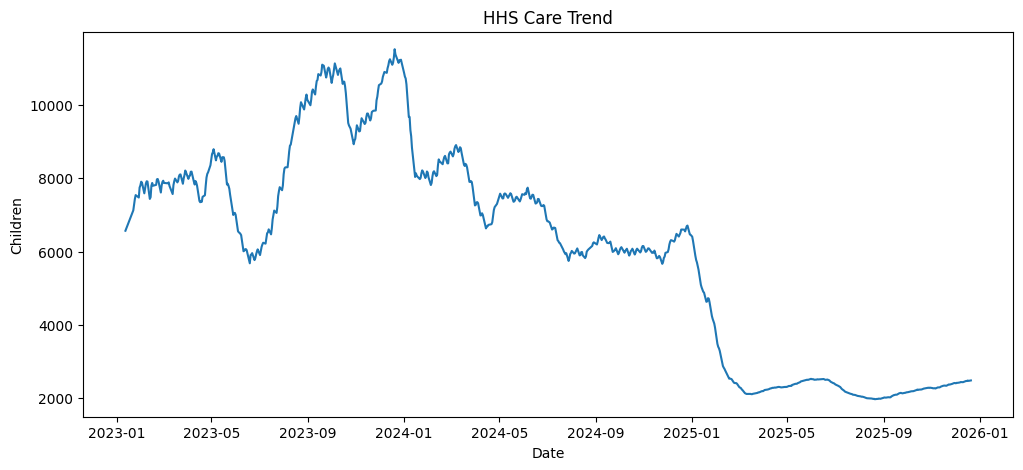

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children in HHS Care'])
plt.title('HHS Care Trend')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

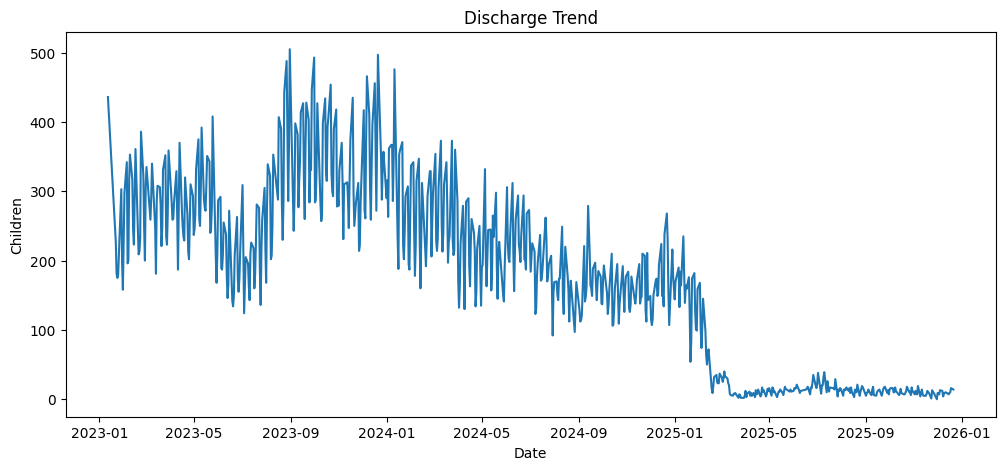

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Children discharged from HHS Care'])
plt.title('Discharge Trend')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

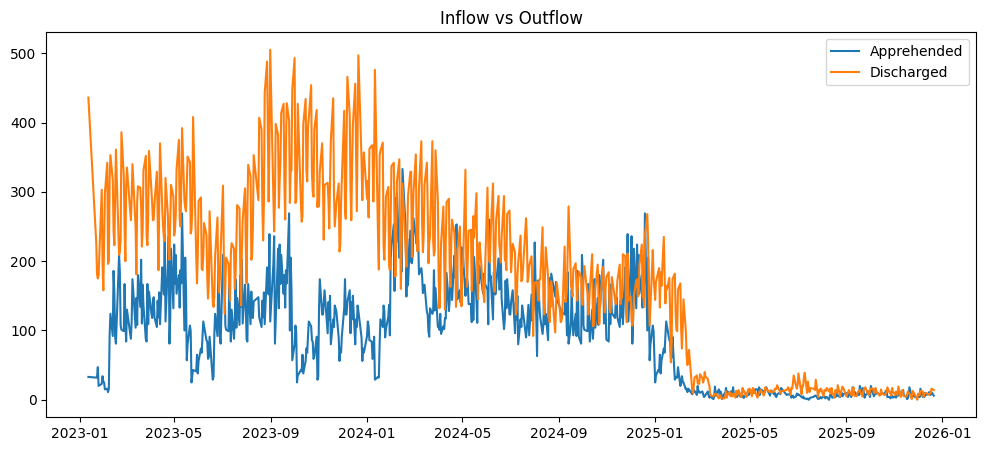

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Children apprehended and placed in CBP custody*'],
         label='Apprehended')

plt.plot(df['Date'], df['Children discharged from HHS Care'],
         label='Discharged')

plt.legend()
plt.title('Inflow vs Outflow')
plt.show()

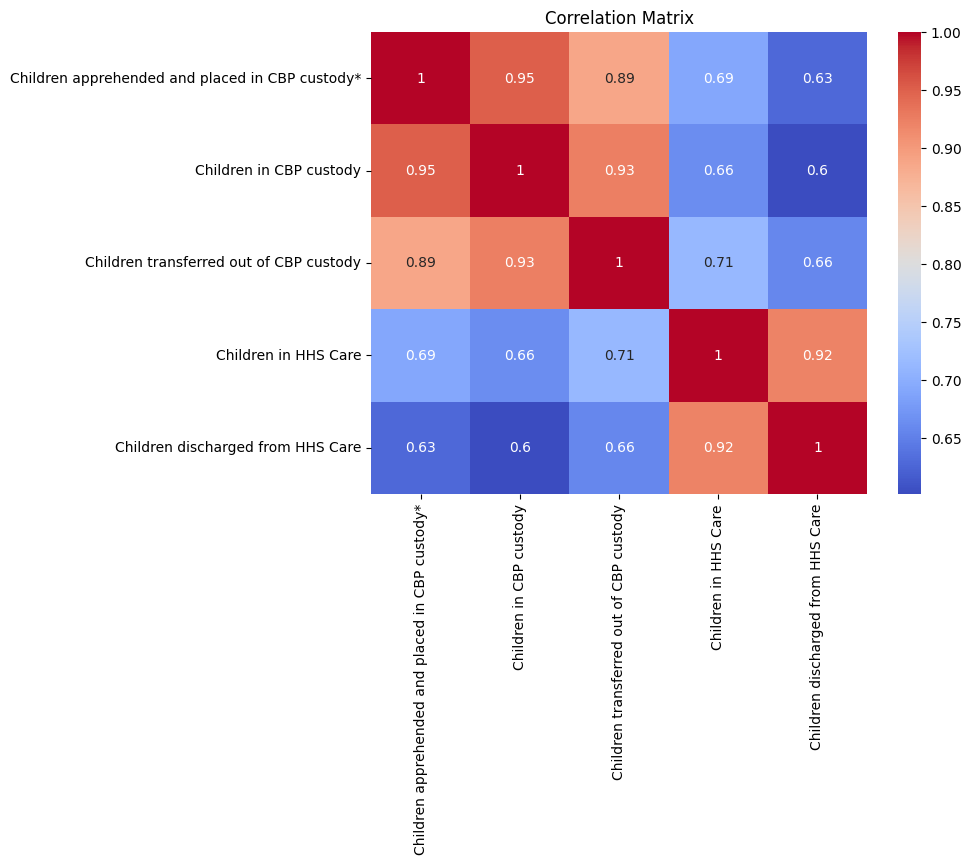

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Children apprehended and placed in CBP custody*',
        'Children in CBP custody',
        'Children transferred out of CBP custody',
        'Children in HHS Care',
        'Children discharged from HHS Care']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

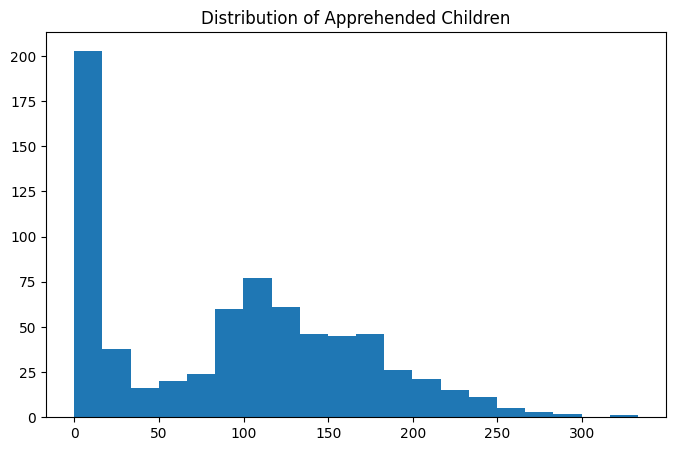

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df['Children apprehended and placed in CBP custody*'],
         bins=20)

plt.title('Distribution of Apprehended Children')
plt.show()

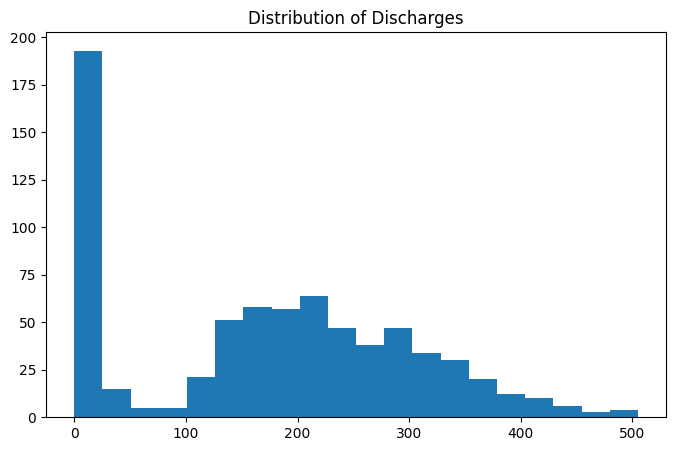

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['Children discharged from HHS Care'],
         bins=20)

plt.title('Distribution of Discharges')
plt.show()

In [19]:
df['Month'] = df['Date'].dt.month_name()

monthly = df.groupby('Month')[[
    'Children apprehended and placed in CBP custody*',
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care'
]].mean()

monthly

,Children apprehended and placed in CBP custody*,Children transferred out of CBP custody,Children discharged from HHS Care
Month,,,
April,102.151515,142.045455,156.742424
August,93.457627,123.389831,166.050847
December,103.625000,136.142857,189.464286
February,115.775862,160.517241,200.275862
January,70.288462,93.769231,224.653846
July,87.158730,121.650794,138.126984
June,90.913793,128.206897,158.982759
March,97.177419,141.903226,183.258065
May,105.836066,148.655738,177.000000


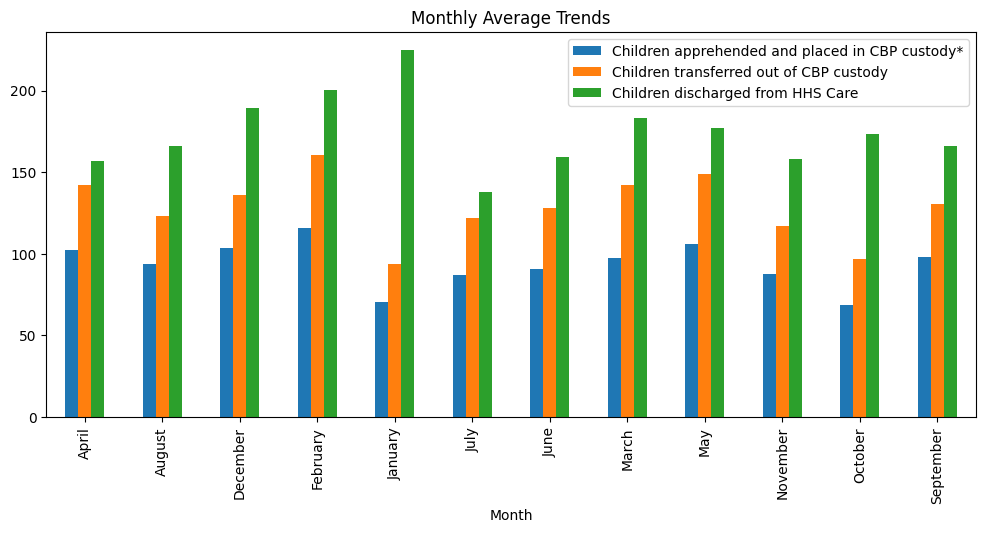

In [20]:
monthly.plot(kind='bar',
             figsize=(12,5))

plt.title("Monthly Average Trends")
plt.show()

In [21]:
df['Day'] = df['Date'].dt.day_name()

weekday = df.groupby('Day')[[
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care'
]].mean()

weekday

,Children transferred out of CBP custody,Children discharged from HHS Care
Day,,
Friday,110.000000,144.000000
Monday,123.731034,157.558621
Sunday,130.061538,206.138462
Thursday,133.414966,205.687075
Tuesday,124.859060,136.114094
Wednesday,131.673469,166.013605


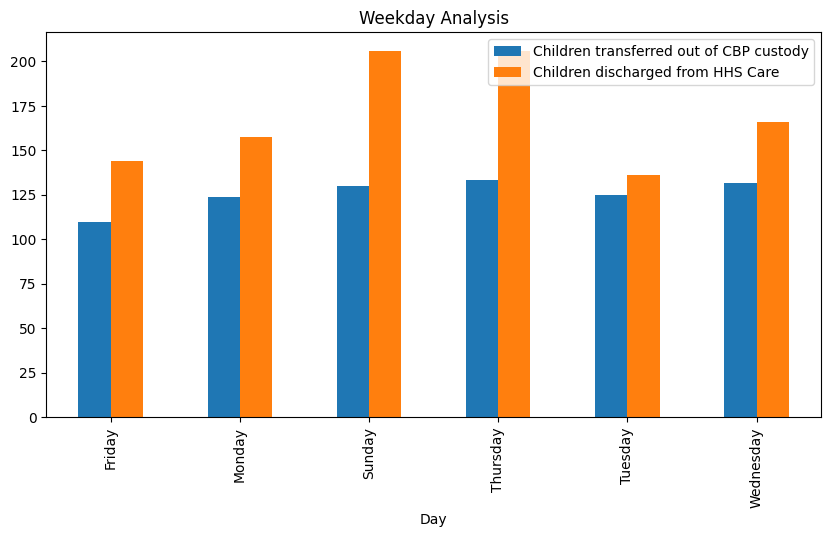

In [22]:
weekday.plot(kind='bar',
             figsize=(10,5))

plt.title("Weekday Analysis")
plt.show()

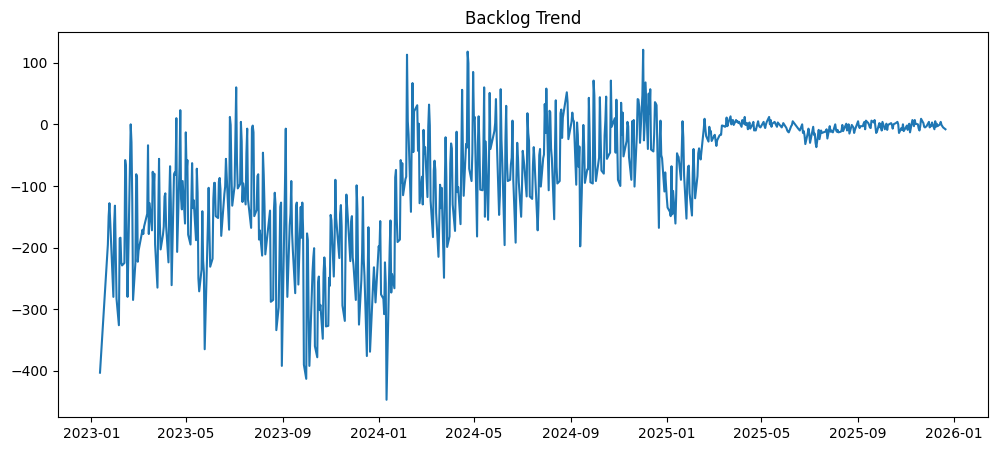

In [23]:
df['Backlog'] = (
    df['Children apprehended and placed in CBP custody*']
    -
    df['Children discharged from HHS Care']
)

plt.figure(figsize=(12,5))

plt.plot(df['Date'],
         df['Backlog'])

plt.title('Backlog Trend')
plt.show()

In [27]:
df['Transfer_Efficiency'] = (
    df['Children transferred out of CBP custody'] / df['Children in CBP custody']
)

print(df['Transfer_Efficiency'].mean())

0.6910176523134812


In [29]:
df['Discharge_Effectiveness'] = (
    df['Children discharged from HHS Care'] / df['Children in HHS Care']
)

print(df['Discharge_Effectiveness'].mean())

0.023737002796523007


In [30]:
df['Pipeline_Throughput'] = (
    df['Children discharged from HHS Care'] / df['Children apprehended and placed in CBP custody*']
)

print(df['Pipeline_Throughput'].mean())

inf


In [31]:
df['Backlog'] = (
    df['Children apprehended and placed in CBP custody*'] - df['Children discharged from HHS Care']
)

print(df['Backlog'].head())

0   -8
1   -5
2   -3
3   -1
4    4
Name: Backlog, dtype: int64


In [32]:
stability = df['Children discharged from HHS Care'].std()

print("Outcome Stability Score:", stability)

Outcome Stability Score: 125.7028405572817


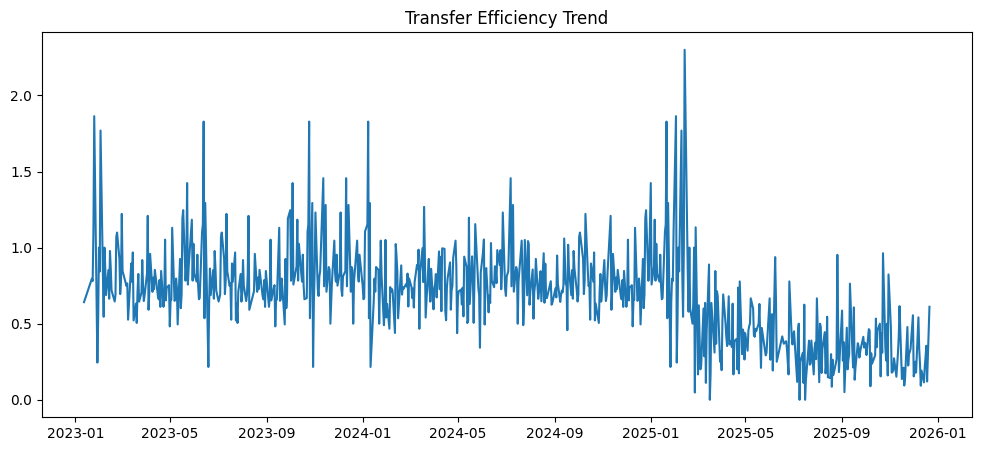

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Transfer_Efficiency'])
plt.title("Transfer Efficiency Trend")
plt.show()

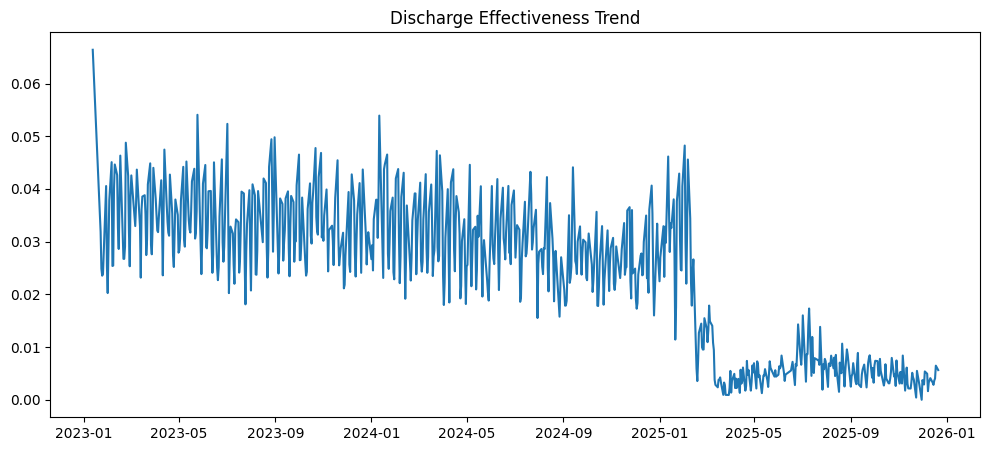

In [34]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Discharge_Effectiveness'])
plt.title("Discharge Effectiveness Trend")
plt.show()

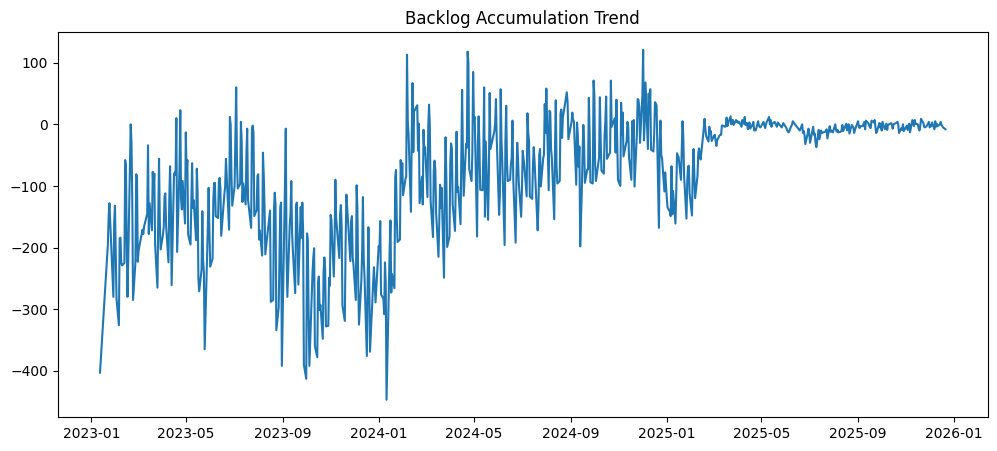

In [35]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Backlog'])
plt.title("Backlog Accumulation Trend")
plt.show()

In [36]:
low_transfer = df[df['Transfer_Efficiency'] < 0.5]

print(low_transfer[['Date', 'Transfer_Efficiency']].head())

        Date  Transfer_Efficiency
1 2025-12-18             0.120000
2 2025-12-17             0.354839
3 2025-12-16             0.277778
4 2025-12-15             0.214286
5 2025-12-14             0.114286


In [37]:
low_discharge = df[df['Discharge_Effectiveness'] < 0.02]

print(low_discharge[['Date', 'Discharge_Effectiveness']].head())

        Date  Discharge_Effectiveness
0 2025-12-21                 0.005636
1 2025-12-18                 0.006472
2 2025-12-17                 0.004031
3 2025-12-16                 0.003647
4 2025-12-15                 0.002834


In [38]:
low_transfer = df[df['Transfer_Efficiency'] < 0.5]

print("Low Transfer Efficiency Days:")
print(low_transfer[['Date', 'Transfer_Efficiency']].head(10))

Low Transfer Efficiency Days:
         Date  Transfer_Efficiency
1  2025-12-18             0.120000
2  2025-12-17             0.354839
3  2025-12-16             0.277778
4  2025-12-15             0.214286
5  2025-12-14             0.114286
6  2025-12-11             0.191489
7  2025-12-10             0.092593
8  2025-12-09             0.233333
9  2025-12-08             0.333333
11 2025-12-04             0.179487


In [39]:
low_discharge = df[df['Discharge_Effectiveness'] < 0.02]

print("Low Discharge Effectiveness Days:")
print(low_discharge[['Date', 'Discharge_Effectiveness']].head(10))

Low Discharge Effectiveness Days:
        Date  Discharge_Effectiveness
0 2025-12-21                 0.005636
1 2025-12-18                 0.006472
2 2025-12-17                 0.004031
3 2025-12-16                 0.003647
4 2025-12-15                 0.002834
5 2025-12-14                 0.003249
6 2025-12-11                 0.004103
7 2025-12-10                 0.003690
8 2025-12-09                 0.003275
9 2025-12-08                 0.001639


In [40]:
top_backlog = df.sort_values(
    by='Backlog',
    ascending=False
)

print(top_backlog[['Date', 'Backlog']].head(10))

          Date  Backlog
259 2024-12-02      121
410 2024-04-23      118
464 2024-02-06      113
409 2024-04-24       99
405 2024-04-30       85
286 2024-10-22       71
301 2024-09-30       71
256 2024-12-05       68
459 2024-02-13       67
395 2024-05-14       60


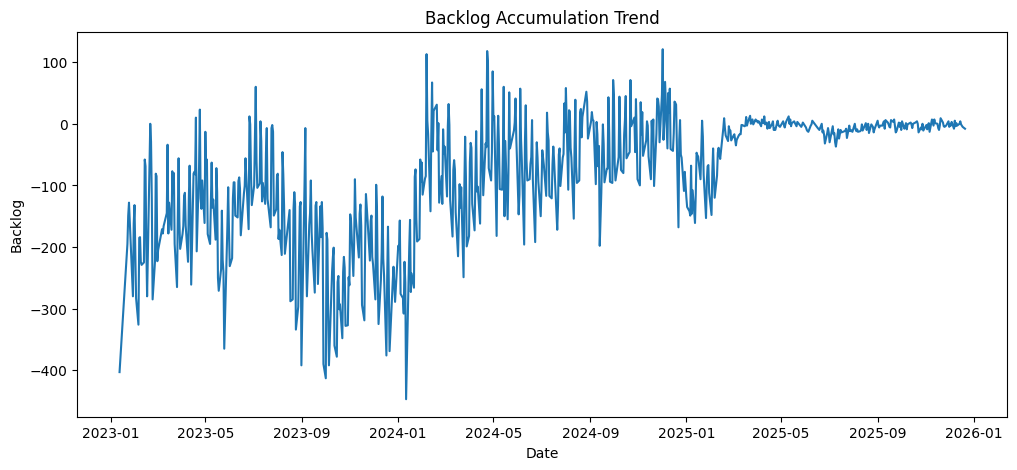

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Backlog'])
plt.title("Backlog Accumulation Trend")
plt.xlabel("Date")
plt.ylabel("Backlog")
plt.show()

In [58]:
%%writefile app.py

import streamlit as st

st.title("Care Transition Efficiency Analytics Dashboard")

st.write("Welcome to the dashboard!")

Overwriting app.py


In [59]:
!ls

 app.py
'HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (1).csv'
'HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program.csv'
 sample_data


In [46]:
# Summary KPIs

print("===== PROJECT INSIGHTS =====")

print("Average Transfer Efficiency:",
      round(df['Transfer_Efficiency'].mean(), 2))

print("Average Discharge Effectiveness:",
      round(df['Discharge_Effectiveness'].mean(), 2))

print("Average Pipeline Throughput:",
      round(df['Pipeline_Throughput'].mean(), 2))

print("Maximum Backlog:",
      df['Backlog'].max())

print("Minimum Backlog:",
      df['Backlog'].min())

print("Outcome Stability Score:",
      round(df['Children discharged from HHS Care'].std(), 2))

===== PROJECT INSIGHTS =====
Average Transfer Efficiency: 0.69
Average Discharge Effectiveness: 0.02
Average Pipeline Throughput: inf
Maximum Backlog: 121
Minimum Backlog: -447
Outcome Stability Score: 125.7


In [50]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.4 MB/s eta 0:00:00


In [55]:
import streamlit as st
import pandas as pd

st.title("Care Transition Efficiency & Placement Outcome Analytics")

df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (1).csv")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Key Metrics")
st.write("Total Records:", len(df))

st.line_chart(df[['Children apprehended and placed in CBP custody*',
                  'Children discharged from HHS Care']])

2026-06-02 08:02:51.459 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.460 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.461 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:02:51.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [57]:
import streamlit as st
import pandas as pd

# Page Configuration
st.set_page_config(
    page_title="Care Transition Analytics",
    layout="wide"
)

st.title("Care Transition Efficiency & Placement Outcome Analytics")

# Load Dataset
df = pd.read_csv(
    "HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (1).csv"
)

# Remove commas and convert to numeric
cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# KPIs
df['Transfer_Efficiency'] = (
    df['Children transferred out of CBP custody']
    /
    df['Children in CBP custody']
)

df['Discharge_Effectiveness'] = (
    df['Children discharged from HHS Care']
    /
    df['Children in HHS Care']
)

df['Backlog'] = (
    df['Children apprehended and placed in CBP custody*']
    -
    df['Children discharged from HHS Care']
)

# Sidebar
st.sidebar.header("Filters")

# Dataset Preview
st.subheader("Dataset Preview")
st.dataframe(df.head())

# KPI Cards
st.subheader("Key Performance Indicators")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Avg Transfer Efficiency",
        round(df['Transfer_Efficiency'].mean(), 2)
    )

with col2:
    st.metric(
        "Avg Discharge Effectiveness",
        round(df['Discharge_Effectiveness'].mean(), 2)
    )

with col3:
    st.metric(
        "Maximum Backlog",
        int(df['Backlog'].max())
    )

# Transfer Trend
st.subheader("Transfer Trend")

st.line_chart(
    df['Children transferred out of CBP custody']
)

# Discharge Trend
st.subheader("Discharge Trend")

st.line_chart(
    df['Children discharged from HHS Care']
)

# Backlog Trend
st.subheader("Backlog Accumulation Trend")

st.line_chart(
    df['Backlog']
)

# CBP vs HHS Care
st.subheader("CBP Custody vs HHS Care")

comparison = df[
    [
        'Children in CBP custody',
        'Children in HHS Care'
    ]
]

st.line_chart(comparison)

# Insights
st.subheader("Key Insights")

st.success(
    """
    • Transfer efficiency indicates how quickly children move from CBP to HHS.

    • Discharge effectiveness measures successful reunification outcomes.

    • Backlog highlights periods where inflow exceeds outflow.

    • Monitoring these KPIs helps identify operational bottlenecks.
    """
)

st.write("Dashboard Completed Successfully")

2026-06-02 08:05:26.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 08:05:26.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar